# Data Exploration — Casting Defect Dataset

This notebook explores the dataset structure, class distribution, and sample images.

In [14]:
import os
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

## 1. Dataset Overview

In [15]:
data_dir = Path('../data/raw')

classes = ['defective', 'non_defective']
print(f'Classes found: {classes}')

class_counts = {}
for cls in classes:
    count = len(list((data_dir / cls).glob('*')))
    class_counts[cls] = count
    print(f'  {cls}: {count} images')

print(f'\nTotal images: {sum(class_counts.values())}')

Classes found: ['defective', 'non_defective']
  defective: 4613 images
  non_defective: 3399 images

Total images: 8012


## 2. Class Distribution

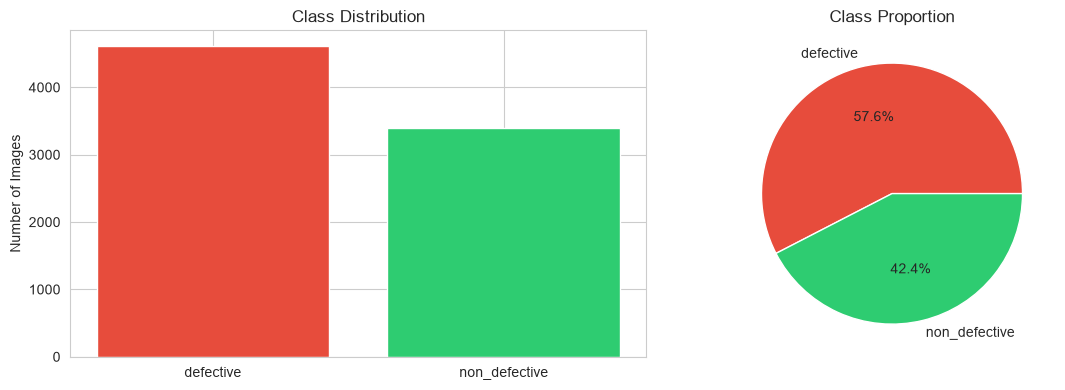

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(class_counts.keys(), class_counts.values(), color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Images')

# Pie chart
axes[1].pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'])
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('../docs/class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Sample Images

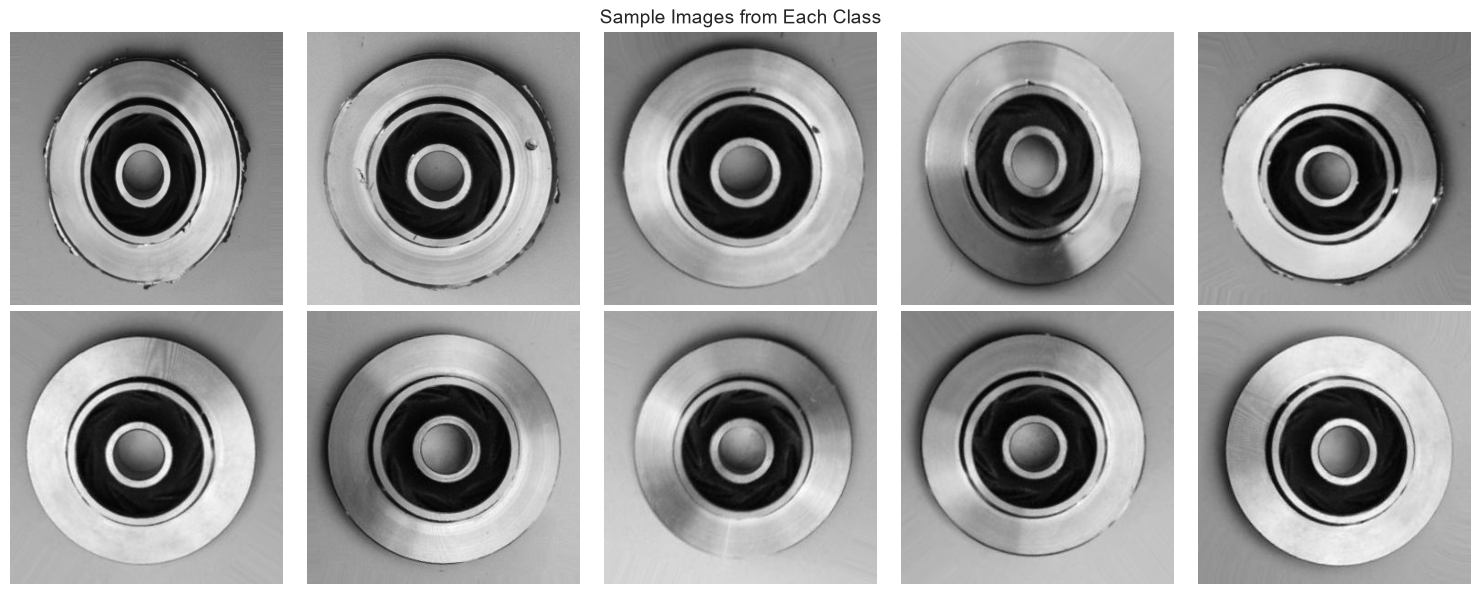

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row, cls in enumerate(classes):
    images = list((data_dir / cls).glob('*'))[:5]
    for col, img_path in enumerate(images):
        img = Image.open(img_path)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=12)

axes[0, 2].set_title('Sample Images from Each Class', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Image Properties

In [18]:
# Check image dimensions and properties
sample_images = list(data_dir.rglob('*.jpeg'))[:100] + list(data_dir.rglob('*.png'))[:100]

widths, heights, modes = [], [], []
for img_path in sample_images:
    with Image.open(img_path) as img:
        widths.append(img.size[0])
        heights.append(img.size[1])
        modes.append(img.mode)

print(f'Image dimensions:')
print(f'  Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'  Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')
print(f'  Modes  — {set(modes)}')

Image dimensions:
  Width  — min: 512, max: 512, mean: 512
  Height — min: 512, max: 512, mean: 512
  Modes  — {'RGB'}


## 5. Pixel Intensity Distribution

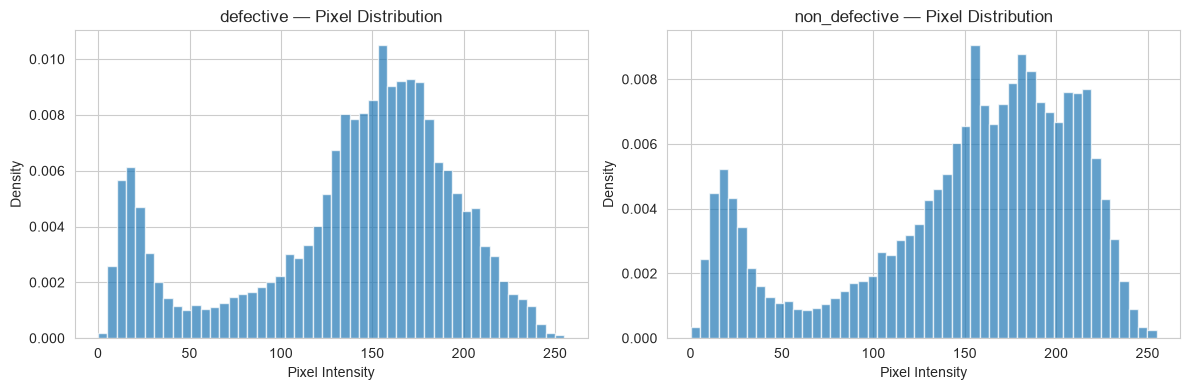

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, cls in enumerate(classes):
    images = list((data_dir / cls).glob('*'))[:50]
    all_pixels = []
    for img_path in images:
        img = np.array(Image.open(img_path).convert('L'))  # grayscale
        all_pixels.extend(img.flatten())
    
    axes[idx].hist(all_pixels, bins=50, alpha=0.7, density=True)
    axes[idx].set_title(f'{cls} — Pixel Distribution')
    axes[idx].set_xlabel('Pixel Intensity')
    axes[idx].set_ylabel('Density')

plt.tight_layout()
plt.savefig('../docs/pixel_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Summary

**Key findings:**
- Dataset contains ~7200 images in 2 classes (defective vs non-defective)
- Slight class imbalance: ~58% defective, ~42% non-defective
- Images are 300x300 grayscale (single-channel)
- Pixel distributions differ between classes — model should be able to learn

**Next steps:**
- Resize to 224x224 for transfer learning compatibility
- Convert to RGB (3-channel) for pretrained model input
- Apply stratified split to maintain class balance across train/val/test